## Pre testing (president)

Here before trying a combination of multiple models, we will define a foundation on how we will run our models.

In [4]:
from preprocessing_class import Preprocessing, load_pres
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC,SVC
from nltk.corpus import stopwords
import numpy as np
import string
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# load dataset
alltxt, alllabs = load_pres("Dataset/corpus.tache1.learn.utf8")
alltxt, alllabs = np.array(alltxt), np.array(alllabs)
# M = -1, C = 1
len(alltxt), len(alllabs), np.unique(alllabs)

(57413, 57413, array([-1,  1]))

In [5]:
# train test split here for test in final prediction

X_train, X_test, y_train, y_test = train_test_split(
    alltxt, alllabs, 
    test_size=0.20, 
    stratify=alllabs, 
    random_state=42
)

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, 
    test_size=0.20, 
    stratify=y_train, 
    random_state=42
)

len(X_train_sub), len(y_train_sub), len(X_val), len(y_val), len(X_train), len(y_train), len(X_test), len(y_test)

(36744, 36744, 9186, 9186, 45930, 45930, 11483, 11483)

### 1.Training time based on vocabulary size, for different modèles

In [6]:
punc = set(string.punctuation + '\n\r\t')
punc.remove("'") # keep the ' for french words 
custom_punctuation = "".join(punc)

prep = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = None, # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

In [18]:
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

final_stopwords_list = stopwords.words('french') # stopwords.words('english') 

def build_vectorizer(name="count", stop_words=None, max_features=None,
                     lowercase=False, strip_accents=None, ngram_range=(1,1), use_idf= True, smooth_idf=True, sublinear_tf=False, 
                     max_df=0.95, min_df=2, preprocessor = lambda x: x):
    if name == "count":
        vectorizer = CountVectorizer(stop_words=stop_words,max_features=max_features,max_df=max_df,min_df=min_df,ngram_range=ngram_range,lowercase=lowercase,
                                     strip_accents=strip_accents, preprocessor=preprocessor)    
        
    elif name == "tfidf":
        vectorizer = TfidfVectorizer(use_idf= use_idf, smooth_idf=smooth_idf, sublinear_tf=sublinear_tf,max_df=max_df, min_df=min_df, max_features=max_features,
                                     stop_words=stop_words, ngram_range=ngram_range,lowercase=lowercase,strip_accents=strip_accents, preprocessor=preprocessor)
    
    return vectorizer

def vectorize_txts(txts,vectorizer):
    X = vectorizer.fit_transform(txts)
    return X

## solver = 'newton-cholesky' to try for logistic regression (n_samples >> n_features * n_classes, especially with one-hot encoded categorical features with rare categories)
def build_model(name="kmeans", n_clusters = 2, max_iter = 1000, penalty='l2', loss='squared_hinge',kernel='rbf',solver='lbfgs'):
    if name == "kmeans":
        return KMeans(n_clusters=n_clusters,max_iter=max_iter) 
    elif name == "rf":
        return RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    elif name == "linear_svm":
        return LinearSVC(class_weight="balanced", penalty=penalty,loss=loss,max_iter=max_iter)
    elif name == "nb":
        return GaussianNB()
    elif name == "svm":
        return SVC(max_iter=max_iter,kernel=kernel)
    elif name == "logreg":
        return LogisticRegression(class_weight="balanced", solver=solver,max_iter=max_iter) 

In [ ]:
import time
import gc
from sklearn.metrics import f1_score, average_precision_score, roc_auc_score

train_time = {}   # {max_feat: {model_name: time}}
val_f1 = {}       # {max_feat: {model_name: f1}}
val_ap = {}       # {max_feat: {model_name: ap}}
val_auc = {}      # {max_feat: {model_name: auc}}
max_features_test = [500, 1000, 5000, 10000]
models_names = ["logreg", "linear_svm", "nb", "rf"]

for max_feat in max_features_test:
    print(f"\n--- max_features = {max_feat} ---")
    train_time[max_feat] = {}
    val_f1[max_feat] = {}
    val_ap[max_feat] = {}
    val_auc[max_feat] = {}

    vectoriser = build_vectorizer(name="count", stop_words=final_stopwords_list, max_features=max_feat, preprocessor=prep)

    vectorised_train_sub = vectoriser.fit_transform(X_train)
    vectorised_val = vectoriser.transform(X_test)

    for model_name in models_names:
        model = build_model(name=model_name, max_iter=2000)

        # GaussianNB requires dense input
        if model_name == "nb":
            X_tr = vectorised_train_sub.toarray()

            start_time = time.time()
            model.fit(X_tr, y_train)
            end_time = time.time()

            del X_tr
            gc.collect()

            elapsed = end_time - start_time
            train_time[max_feat][model_name] = elapsed

            X_v = vectorised_val.toarray()

            y_pred_val = model.predict(X_v)
            y_score_val = model.predict_proba(X_v)[:, 1]
            f1 = f1_score(y_test, y_pred_val, average='macro')
            ap = average_precision_score(y_test, y_score_val)
            auc = roc_auc_score(y_test, y_score_val)
            val_f1[max_feat][model_name] = f1
            val_ap[max_feat][model_name] = ap
            val_auc[max_feat][model_name] = auc

            print(f"  {model_name}: {elapsed:.2f}s  |  val F1: {f1:.4f}  |  val AP: {ap:.4f}  |  val AUC: {auc:.4f}")

            # free memory
            del model, X_v, y_pred_val, y_score_val
            gc.collect()

        else:
            X_tr = vectorised_train_sub
            X_v = vectorised_val

            start_time = time.time()
            model.fit(X_tr, y_train)
            end_time = time.time()

            elapsed = end_time - start_time
            train_time[max_feat][model_name] = elapsed

            y_pred_val = model.predict(X_v)
            y_score_val = model.decision_function(X_v)
            f1 = f1_score(y_test, y_pred_val, average='macro')
            ap = average_precision_score(y_test, y_score_val, pos_label=1)
            auc = roc_auc_score(y_test, y_score_val)
            val_f1[max_feat][model_name] = f1
            val_ap[max_feat][model_name] = ap
            val_auc[max_feat][model_name] = auc

            print(f"  {model_name}: {elapsed:.2f}s  |  val F1: {f1:.4f}  |  val AP: {ap:.4f}  |  val AUC: {auc:.4f}")

            # free memory
            del model, X_tr, X_v, y_pred_val, y_score_val
            gc.collect()

    del vectorised_train_sub, vectorised_val, vectoriser
    gc.collect()

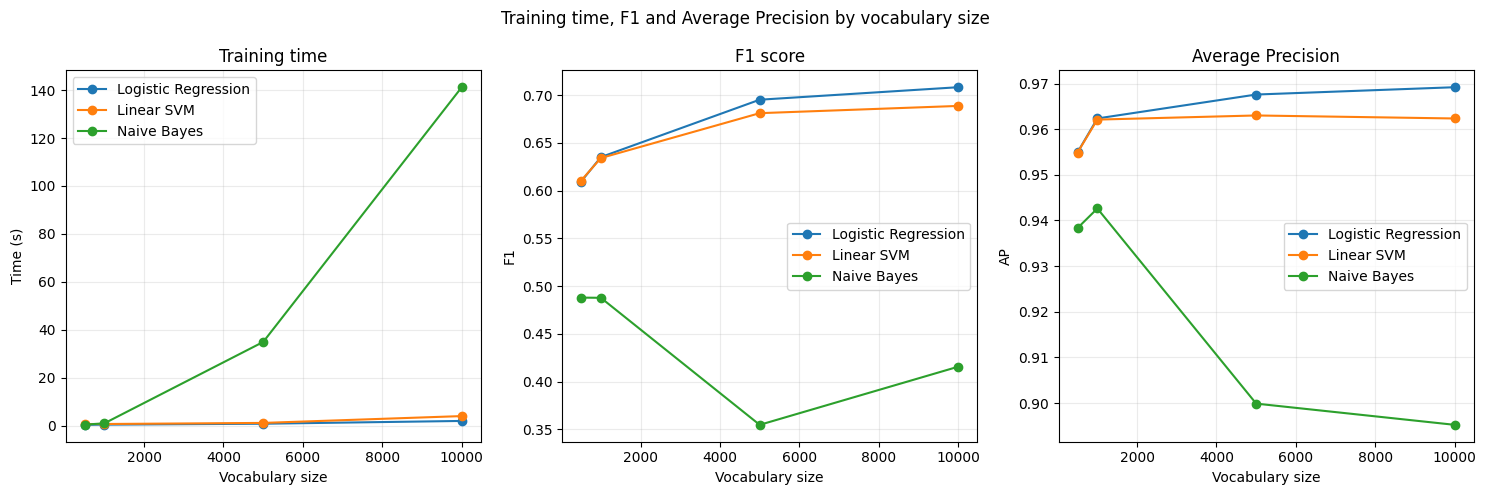

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for model_name in models_names:
    if model_name == "nb":
        label = "Naive Bayes"
    elif model_name == "logreg":
        label = "Logistic Regression"
    elif model_name == "linear_svm":
        label = "Linear SVM"
    times = [train_time[mf][model_name] for mf in max_features_test]
    f1s   = [val_f1[mf][model_name]     for mf in max_features_test]
    aps   = [val_ap[mf][model_name]     for mf in max_features_test]
    axes[0].plot(max_features_test, times, marker="o", label=label)
    axes[1].plot(max_features_test, f1s,   marker="o", label=label)
    axes[2].plot(max_features_test, aps,   marker="o", label=label)

axes[0].set_title("Training time")
axes[0].set_xlabel("Vocabulary size")
axes[0].set_ylabel("Time (s)")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].set_title("F1 score")
axes[1].set_xlabel("Vocabulary size")
axes[1].set_ylabel("F1")
axes[1].legend()
axes[1].grid(alpha=0.25)

axes[2].set_title("Average Precision")
axes[2].set_xlabel("Vocabulary size")
axes[2].set_ylabel("AP")
axes[2].legend()
axes[2].grid(alpha=0.25)

plt.suptitle("Training time, F1 and Average Precision by vocabulary size")
plt.tight_layout()
# plt.savefig("images/pretest/training_time_f1_by_vocab_size.pdf")
plt.show()


In [ ]:
# Code with averaging !!
import time
import gc
from sklearn.metrics import f1_score, average_precision_score, roc_auc_score

n_runs = 3  # number of repetitions
train_time = {}   # {max_feat: {model_name: [time1, time2, ...]}}
val_f1 = {}       # {max_feat: {model_name: [f1_1, f1_2, ...]}}
val_ap = {}       # {max_feat: {model_name: [ap_1, ap_2, ...]}}
val_auc = {}      # {max_feat: {model_name: [auc_1, auc_2, ...]}}
max_features_test = [500, 1000, 5000, 10000]
models_names = ["logreg", "linear_svm", "nb", "rf"]

for max_feat in max_features_test:
    print(f"\n--- max_features = {max_feat} ---")
    train_time[max_feat] = {}
    val_f1[max_feat] = {}
    val_ap[max_feat] = {}
    val_auc[max_feat] = {}

    vectoriser = build_vectorizer(name="count", stop_words=final_stopwords_list, max_features=max_feat, preprocessor=prep)

    vectorised_train_sub = vectoriser.fit_transform(X_train)
    vectorised_val = vectoriser.transform(X_test)

    for model_name in models_names:
        times = []
        f1s = []
        aps = []
        aucs = []

        for run in range(n_runs):
            model = build_model(name=model_name, max_iter=2000)

            # GaussianNB requires dense input
            if model_name == "nb":
                X_tr = vectorised_train_sub.toarray()
                X_v = vectorised_val.toarray()

                start_time = time.time()
                model.fit(X_tr, y_train)
                end_time = time.time()

                y_pred_val = model.predict(X_v)
                y_score_val = model.predict_proba(X_v)[:, 1]

                del X_tr
                gc.collect()

            else:
                X_tr = vectorised_train_sub
                X_v = vectorised_val

                start_time = time.time()
                model.fit(X_tr, y_train)
                end_time = time.time()

                y_pred_val = model.predict(X_v)
                if hasattr(model, "predict_proba"):
                    y_score_val = model.predict_proba(X_v)[:, 1]
                else:  # fallback for models with decision_function
                    y_score_val = model.decision_function(X_v)

            # record metrics
            elapsed = end_time - start_time
            times.append(elapsed)
            f1s.append(f1_score(y_test, y_pred_val, average='macro'))
            aps.append(average_precision_score(y_test, y_score_val, pos_label=1))
            aucs.append(roc_auc_score(y_test, y_score_val))

            # free memory
            del model, X_v, y_pred_val, y_score_val
            gc.collect()

        # store all runs
        train_time[max_feat][model_name] = times
        val_f1[max_feat][model_name] = f1s
        val_ap[max_feat][model_name] = aps
        val_auc[max_feat][model_name] = aucs

        print(f"  {model_name}: times = {times}  |  F1s = {f1s}  |  APs = {aps}  |  AUCs = {aucs}")

    del vectorised_train_sub, vectorised_val, vectoriser
    gc.collect()


--- max_features = 500 ---
  logreg: times = [0.2986009120941162, 0.2908334732055664, 0.24782419204711914]  |  F1s = [0.6054699492309641, 0.6054699492309641, 0.6054699492309641]  |  APs = [0.9532329923341989, 0.9532329923341989, 0.9532329923341989]  |  AUCs = [0.7772794167101177, 0.7772794167101177, 0.7772794167101177]
  linear_svm: times = [0.660574197769165, 0.6435985565185547, 0.6397361755371094]  |  F1s = [0.6079765852344715, 0.6079765852344715, 0.6079765852344715]  |  APs = [0.9532825043099185, 0.9532825043099185, 0.9532825043099185]  |  AUCs = [0.7770486099318833, 0.7770486099318833, 0.7770486099318833]
  nb: times = [3.268500566482544, 3.6493260860443115, 2.687218189239502]  |  F1s = [0.4802936294471143, 0.4802936294471143, 0.4802936294471143]  |  APs = [0.9387494432921275, 0.9387494432921275, 0.9387494432921275]  |  AUCs = [0.7378644313170037, 0.7378644313170037, 0.7378644313170037]
  rf: times = [83.92493939399719, 95.86335110664368, 89.1626524925232]  |  F1s = [0.57824032407

In [ ]:
# associated plot
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 4, figsize=(20, 5))  # 4 subplots now

for model_name in models_names:
    if model_name == "nb":
        label = "Naive Bayes"
    elif model_name == "logreg":
        label = "Logistic Regression"
    elif model_name == "linear_svm":
        label = "Linear SVM"
    elif model_name == "rf":
        label = "Random Forest"

    # compute mean and std for each metric across runs
    times_mean = [np.mean(train_time[mf][model_name]) for mf in max_features_test]
    times_std  = [np.std(train_time[mf][model_name])  for mf in max_features_test]

    f1_mean = [np.mean(val_f1[mf][model_name]) for mf in max_features_test]
    f1_std  = [np.std(val_f1[mf][model_name])  for mf in max_features_test]

    ap_mean = [np.mean(val_ap[mf][model_name]) for mf in max_features_test]
    ap_std  = [np.std(val_ap[mf][model_name])  for mf in max_features_test]

    auc_mean = [np.mean(val_auc[mf][model_name]) for mf in max_features_test]
    auc_std  = [np.std(val_auc[mf][model_name])  for mf in max_features_test]

    # plot with error bars
    axes[0].errorbar(max_features_test, times_mean, yerr=times_std, marker="o", capsize=5, label=label)
    axes[1].errorbar(max_features_test, f1_mean,   yerr=f1_std,  marker="o", capsize=5, label=label)
    axes[2].errorbar(max_features_test, ap_mean,   yerr=ap_std,  marker="o", capsize=5, label=label)
    axes[3].errorbar(max_features_test, auc_mean,  yerr=auc_std, marker="o", capsize=5, label=label)

# axes titles and labels
axes[0].set_title("Training time")
axes[0].set_xlabel("Vocabulary size")
axes[0].set_ylabel("Time (s)")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].set_title("F1 score")
axes[1].set_xlabel("Vocabulary size")
axes[1].set_ylabel("F1")
axes[1].legend()
axes[1].grid(alpha=0.25)

axes[2].set_title("Average Precision")
axes[2].set_xlabel("Vocabulary size")
axes[2].set_ylabel("AP")
axes[2].legend()
axes[2].grid(alpha=0.25)

axes[3].set_title("AUC score")
axes[3].set_xlabel("Vocabulary size")
axes[3].set_ylabel("AUC")
axes[3].legend()
axes[3].grid(alpha=0.25)

plt.suptitle("Training time, F1, AP, and AUC by vocabulary size (mean ± std)")
plt.tight_layout()
plt.savefig("images/pretest/training_time_f1_ap_auc_by_vocab_size.pdf")
plt.show()

### 2. Cross validation vs split

In [64]:
# repeated hold-out split (5 runs): Average Precision and F1 mean/std
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, f1_score
from sklearn.linear_model import LogisticRegression
import numpy as np

np.random.seed(0)
n_runs = 5
max_feat = 10000
split_ap_scores = []
split_f1_scores = []

for seed in range(n_runs): # on train dataset
    X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(
        X_train,
        y_train,
        test_size=0.2,
        stratify=y_train
    )

    vectoriser = build_vectorizer(
        name="count",
        stop_words=final_stopwords_list,
        max_features=max_feat,
        preprocessor=prep
    )

    X_train_vec = vectoriser.fit_transform(X_train_sub)
    X_test_vec = vectoriser.transform(X_test_sub)

    model = LogisticRegression(solver="lbfgs", max_iter=2000)
    model.fit(X_train_vec, y_train_sub)

    y_score = model.decision_function(X_test_vec)
    y_pred = model.predict(X_test_vec)

    ap = average_precision_score(y_test_sub, y_score)
    f1 = f1_score(y_test_sub, y_pred, average='macro')

    split_ap_scores.append(ap)
    split_f1_scores.append(f1)

split_ap_scores = np.array(split_ap_scores)
split_f1_scores = np.array(split_f1_scores)

print("Repeated split (5 runs)")
print(f"AP scores: {np.round(split_ap_scores, 4)}")
print(f"AP mean:   {split_ap_scores.mean():.4f}")
print(f"AP std:    {split_ap_scores.std():.4f}")
print()
print(f"F1 scores: {np.round(split_f1_scores, 4)}")
print(f"F1 mean:   {split_f1_scores.mean():.4f}")
print(f"F1 std:    {split_f1_scores.std():.4f}")

Repeated split (5 runs)
AP scores: [0.9729 0.9689 0.9718 0.9712 0.9706]
AP mean:   0.9711
AP std:    0.0013

F1 scores: [0.7051 0.7034 0.7222 0.7153 0.7034]
F1 mean:   0.7099
F1 std:    0.0076


In [65]:
# 5-fold cross-validation (manual loop): Average Precision and F1 mean/variance/std
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score, f1_score
import gc

max_feat = 10000
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

cv_ap_scores = []
cv_f1_scores = []

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X_train, y_train), start=1):
    X_train_fold = X_train[train_idx]
    y_train_fold = y_train[train_idx]
    X_test_fold = X_train[test_idx]
    y_test_fold = y_train[test_idx]

    vectoriser = build_vectorizer(
        name="count",
        stop_words=final_stopwords_list,
        max_features=max_feat,
        preprocessor=prep
    )

    X_train_vec = vectoriser.fit_transform(X_train_fold)
    X_test_vec = vectoriser.transform(X_test_fold)

    model = LogisticRegression(solver="lbfgs", max_iter=2000)
    model.fit(X_train_vec, y_train_fold)

    y_score = model.decision_function(X_test_vec)
    y_pred = model.predict(X_test_vec)

    ap = average_precision_score(y_test_fold, y_score, pos_label=1)
    f1 = f1_score(y_test_fold, y_pred, average='macro')

    cv_ap_scores.append(ap)
    cv_f1_scores.append(f1)

    print(f"Fold {fold_idx}/5 - AP: {ap:.4f}, F1: {f1:.4f}")

    del vectoriser, model, X_train_vec, X_test_vec, y_score, y_pred
    gc.collect()

cv_ap_scores = np.array(cv_ap_scores)
cv_f1_scores = np.array(cv_f1_scores)

print("5-fold CV (manual)")
print(f"AP scores: {np.round(cv_ap_scores, 4)}")
print(f"AP mean:      {cv_ap_scores.mean():.4f}")
print(f"AP variance:  {cv_ap_scores.var():.6f}")
print(f"AP std:       {cv_ap_scores.std():.4f}")
print()
print(f"F1 scores: {np.round(cv_f1_scores, 4)}")
print(f"F1 mean:      {cv_f1_scores.mean():.4f}")
print(f"F1 variance:  {cv_f1_scores.var():.6f}")
print(f"F1 std:       {cv_f1_scores.std():.4f}")

Fold 1/5 - AP: 0.9709, F1: 0.7142
Fold 2/5 - AP: 0.9685, F1: 0.6999
Fold 3/5 - AP: 0.9703, F1: 0.7065
Fold 4/5 - AP: 0.9705, F1: 0.7161
Fold 5/5 - AP: 0.9712, F1: 0.6993
5-fold CV (manual)
AP scores: [0.9709 0.9685 0.9703 0.9705 0.9712]
AP mean:      0.9703
AP variance:  0.000001
AP std:       0.0009

F1 scores: [0.7142 0.6999 0.7065 0.7161 0.6993]
F1 mean:      0.7072
F1 variance:  0.000049
F1 std:       0.0070


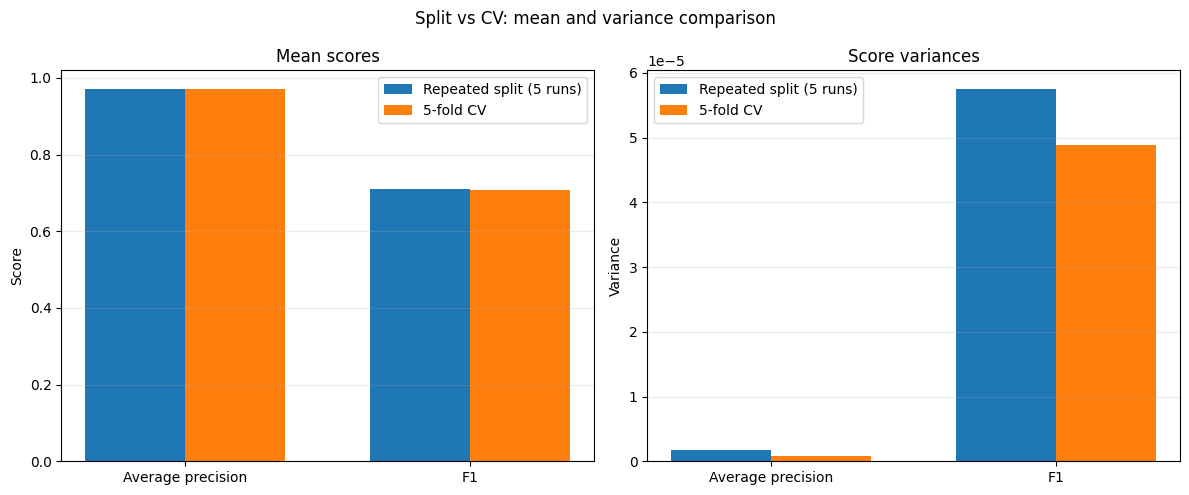

In [68]:
# plot comparison: repeated split vs 5-fold CV (mean and variance)
import numpy as np
import matplotlib.pyplot as plt

metrics = ["Average precision", "F1"]

split_means = [split_ap_scores.mean(), split_f1_scores.mean()]
cv_means = [cv_ap_scores.mean(), cv_f1_scores.mean()]

split_vars = [split_ap_scores.var(), split_f1_scores.var()]
cv_vars = [cv_ap_scores.var(), cv_f1_scores.var()]

x = np.arange(len(metrics))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Means
axes[0].bar(x - width/2, split_means, width, label="Repeated split (5 runs)")
axes[0].bar(x + width/2, cv_means, width, label="5-fold CV")
axes[0].set_title("Mean scores")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylabel("Score")
axes[0].grid(axis="y", alpha=0.25)
axes[0].legend()

# Variances
axes[1].bar(x - width/2, split_vars, width, label="Repeated split (5 runs)")
axes[1].bar(x + width/2, cv_vars, width, label="5-fold CV")
axes[1].set_title("Score variances")
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].set_ylabel("Variance")
axes[1].grid(axis="y", alpha=0.25)
axes[1].legend()

plt.suptitle("Split vs CV: mean and variance comparison")
plt.tight_layout()
plt.savefig("images/pretest/split_cv.pdf")
plt.show()

### 3. Test of different preprocessing

Here we test different preprocessing to see what is the most efficient. We will use Tfidf vectorizer and logistic regression to evaluate.
- 1. no preprocessing
- 2. lower case and no punctuation
- 3. add remove accents
- 4. add lemmatisation 
- 5. add stemming (no lemma)

In [69]:
punc = set(string.punctuation + '\n\r\t')
punc.remove("'") # keep the ' for french words 
custom_punctuation = "".join(punc)

#lower case and no punctuation
prep2 = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = None, # stem faster
                pos_tagging = False, # to check
                all_capital = False, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

#add remove accents
prep3 = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = None, # stem faster
                pos_tagging = False, # to check
                all_capital = False, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = True, 
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )
# add lemma
prep4 = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = "lemma", # stem faster
                pos_tagging = False, # to check
                all_capital = False, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = True,  # check if changes!!!!
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

# add stemming
prep5 = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = "stem", # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = True, 
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

from nltk.stem import SnowballStemmer 
import spacy, unicodedata

stopwords_no_accent = [unicodedata.normalize('NFD', text).encode('ascii', 'ignore').decode("utf-8") for text in final_stopwords_list]

stemmer = SnowballStemmer("french")
stemmed_stopwords = [stemmer.stem(word) for word in final_stopwords_list]
stemmed_stopw_no_accent = [unicodedata.normalize('NFD', text).encode('ascii', 'ignore').decode("utf-8") for text in stemmed_stopwords]


nlp_lem = spacy.load("fr_core_news_sm", disable=["parser", "ner"])
lemma_stopwords = []

for word in final_stopwords_list:
    doc = nlp_lem(word)
    for token in doc:
        lemma_stopwords.append(token.lemma_.lower())


lemma_stopwords_no_accent = [unicodedata.normalize('NFD', text).encode('ascii', 'ignore').decode("utf-8") for text in lemma_stopwords]

In [ ]:
from sklearn.metrics import average_precision_score, f1_score
import pandas as pd
import gc

preprocessors = {
    "prep1_raw": [None, final_stopwords_list],
    "prep2_lower+punct": [prep2, final_stopwords_list],
    "prep3_+accent_removal": [prep3, stopwords_no_accent],
    "prep4_+lemmatisation": [prep4,lemma_stopwords_no_accent],
    "prep5_+stemming": [prep5,stemmed_stopw_no_accent]
}

results = []

for name, el in preprocessors.items():
    preproc, stop_w = el[0], el[1]

    if preproc is None:
        vectoriser = build_vectorizer(
            name="tfidf",
            stop_words=stop_w,
            max_features=10000
        )
    else:
        vectoriser = build_vectorizer(
            name="tfidf",
            stop_words=stop_w,
            max_features=10000,
            preprocessor=preproc,
        )

    X_train_vec = vectoriser.fit_transform(X_train)
    X_test_vec = vectoriser.transform(X_test)

    model = LogisticRegression(solver="lbfgs", max_iter=2000)
    model.fit(X_train_vec, y_train)

    y_train_score = model.decision_function(X_train_vec)
    y_test_score = model.decision_function(X_test_vec)
    y_train_pred = model.predict(X_train_vec)
    y_test_pred = model.predict(X_test_vec)

    train_ap = average_precision_score(y_train, y_train_score,  average='macro')
    test_ap = average_precision_score(y_test, y_test_score,  average='macro')
    train_f1 = f1_score(y_train, y_train_pred, average='macro')
    test_f1 = f1_score(y_test, y_test_pred, average='macro')

    results.append({
        "preprocessor": name,
        "train_ap": train_ap,
        "test_ap": test_ap,
        "train_f1": train_f1,
        "test_f1": test_f1,
    })

    print(f"{name}")
    print(f"  train AP: {train_ap:.4f} | test AP: {test_ap:.4f}")
    print(f"  train F1: {train_f1:.4f} | test F1: {test_f1:.4f}")
    print()

    del vectoriser, model, X_train_vec, X_test_vec, y_train_score, y_test_score, y_train_pred, y_test_pred
    gc.collect()

results_df = pd.DataFrame(results).sort_values(["test_f1", "test_ap"], ascending=False).reset_index(drop=True)
display(results_df)

prep1_raw
prep1_raw
  train AP: 0.9884 | test AP: 0.9758
  train F1: 0.7150 | test F1: 0.6790

prep2_lower+punct
prep2_lower+punct
  train AP: 0.9862 | test AP: 0.9711
  train F1: 0.6909 | test F1: 0.6513

prep3_+accent_removal
prep3_+accent_removal
  train AP: 0.9860 | test AP: 0.9709
  train F1: 0.6837 | test F1: 0.6453

prep4_+lemmatisation


/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['etier', 'fumer', 'luir'] not in stop_words.
  warnings.warn(


prep4_+lemmatisation
  train AP: 0.9842 | test AP: 0.9704
  train F1: 0.6887 | test F1: 0.6626

prep5_+stemming
prep5_+stemming
  train AP: 0.9829 | test AP: 0.9696
  train F1: 0.6782 | test F1: 0.6540



,preprocessor,train_ap,test_ap,train_f1,test_f1
0,prep1_raw,0.988380,0.975773,0.714983,0.678981
1,prep4_+lemmatisation,0.984158,0.970367,0.688672,0.662565
2,prep5_+stemming,0.982852,0.969649,0.678165,0.654012
3,prep2_lower+punct,0.986247,0.971132,0.690910,0.651251
4,prep3_+accent_removal,0.985967,0.970927,0.683722,0.645265


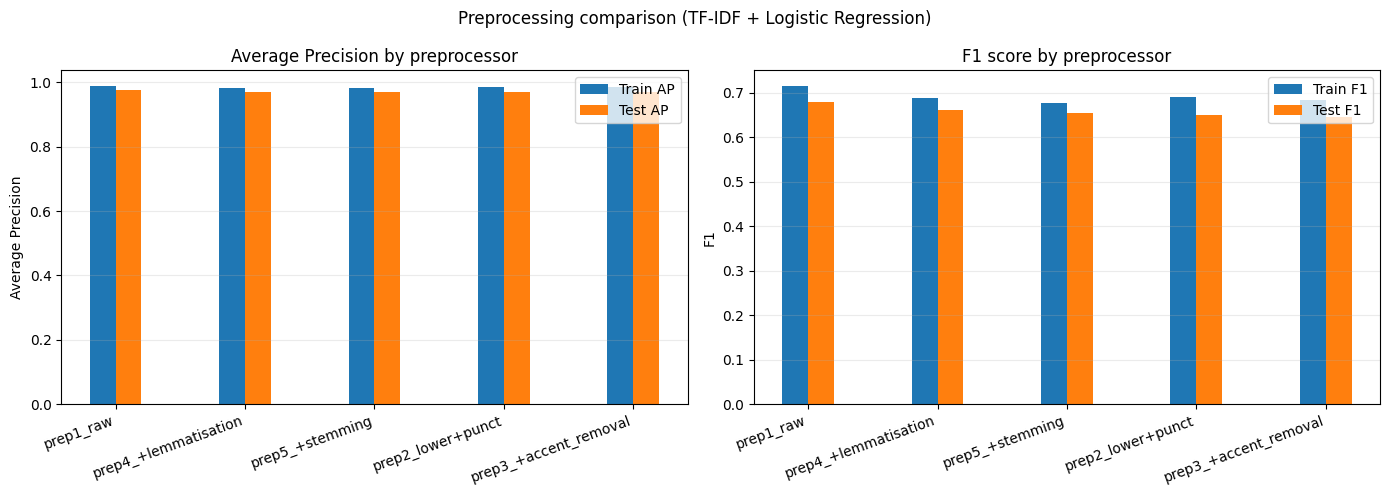

In [72]:

# plot preprocessing comparison: train vs test AP and F1
labels = results_df["preprocessor"].tolist()
x = np.arange(len(labels))
width = 0.2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(x - width/2, results_df["train_ap"], width, label="Train AP")
axes[0].bar(x + width/2, results_df["test_ap"],  width, label="Test AP")
axes[0].set_title("Average Precision by preprocessor")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=20, ha="right")
axes[0].set_ylabel("Average Precision")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(x - width/2, results_df["train_f1"], width, label="Train F1")
axes[1].bar(x + width/2, results_df["test_f1"],  width, label="Test F1")
axes[1].set_title("F1 score by preprocessor")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=20, ha="right")
axes[1].set_ylabel("F1")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.25)

plt.suptitle("Preprocessing comparison (TF-IDF + Logistic Regression)")
plt.tight_layout()
# plt.savefig("images/pretest/preprocessing_comparison.pdf")
plt.show()


### Test with n-grams with little preprocessing

In [17]:
prep = Preprocessing(low_case = False,
                rm_punctuation = True,
                rm_number = True,
                word_norm = None, # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

In [18]:
ranges_ngram = [(1,1), (1,2), (2,2), (1,3), (2,3), (3,3)]

for t in ranges_ngram:
    vectoriser = build_vectorizer(
            name="tfidf",
            stop_words=final_stopwords_list,
            max_features=10000,
            ngram_range=t, # unigrams + bigrams
            preprocessor=prep
    )

    X_train_vec = vectoriser.fit_transform(X_train)
    X_test_vec = vectoriser.transform(X_test)
    print(len(vectoriser.vocabulary_))

    model = LogisticRegression(solver="lbfgs", max_iter=2000)
    model.fit(X_train_vec, y_train)

    y_train_score = model.decision_function(X_train_vec)
    y_test_score = model.decision_function(X_test_vec)
    y_train_pred = model.predict(X_train_vec)
    y_test_pred = model.predict(X_test_vec)

    train_ap = average_precision_score(y_train, y_train_score,  average='macro')
    test_ap = average_precision_score(y_test, y_test_score,  average='macro')
    train_f1 = f1_score(y_train, y_train_pred, average='macro')
    test_f1 = f1_score(y_test, y_test_pred, average='macro')

    print(f"n-gram range: {t}")
    print(f"  train AP: {train_ap:.4f} | test AP: {test_ap:.4f}")
    print(f"  train F1: {train_f1:.4f} | test F1: {test_f1:.4f}")

10000
n-gram range: (1, 1)
  train AP: 0.9873 | test AP: 0.9756
  train F1: 0.7216 | test F1: 0.6686
10000
n-gram range: (1, 2)
  train AP: 0.9887 | test AP: 0.9767
  train F1: 0.7263 | test F1: 0.6820
10000
n-gram range: (2, 2)
  train AP: 0.9798 | test AP: 0.9556
  train F1: 0.6125 | test F1: 0.5817
10000
n-gram range: (1, 3)
  train AP: 0.9888 | test AP: 0.9768
  train F1: 0.7296 | test F1: 0.6849
10000
n-gram range: (2, 3)
  train AP: 0.9790 | test AP: 0.9552
  train F1: 0.6118 | test F1: 0.5823
10000
n-gram range: (3, 3)
  train AP: 0.9345 | test AP: 0.9027
  train F1: 0.4963 | test F1: 0.4848


### Test of different embeddings

In [ ]:
# test with tfidf, countvect, embeddings trained, pretrained and hugging face   

CountVectoriser

In [10]:
from sklearn import preprocessing
from sklearn.metrics import roc_auc_score, f1_score, average_precision_score, precision_score, recall_score

def eval_test_vect(model, kwargs, X_train, y_train, X_test, y_test):
    # pass the vectorized train and tes    
    # scaling
    scaler = preprocessing.StandardScaler(with_mean=False).fit(X_train) # avoid dense matrix
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    clf = model(**kwargs)
    clf.fit(X_train_scaled, y_train)

    y_pred_train = clf.predict(X_train_scaled)
    ypred_train_prob = clf.predict_proba(X_train_scaled)[:, 1]  # probas for ROC

    y_pred = clf.predict(X_test_scaled)
    ypred_prob = clf.predict_proba(X_test_scaled)[:, 1]

    f1_train, f1_test = f1_score(y_train, y_pred_train, average="macro"), f1_score(y_test, y_pred, average="macro")
    ap_train, ap_test = average_precision_score(y_train, y_pred_train), average_precision_score(y_test, y_pred)
    auc_train, auc_test = roc_auc_score(y_train, ypred_train_prob), roc_auc_score(y_test, ypred_prob)
    prec_train, prec_test = precision_score(y_train, y_pred_train, average="macro"), precision_score(y_test, y_pred, average="macro")
    rec_train, rec_test = recall_score(y_train, y_pred_train, average="macro"), recall_score(y_test, y_pred, average="macro")

    final_train_metrics = {
        "AUC": auc_train,
        "F1": f1_train,
        "Average Precision": ap_train,
        "Recall": rec_train,
        "Precision": prec_train,
    }

    test_metrics = {
        "AUC": auc_test,
        "F1": f1_test,
        "Average Precision": ap_test,
        "Recall": rec_test,
        "Precision": prec_test,
    }

    # print summary
    print("Final Train Results:")
    for metric_name, metric_value in final_train_metrics.items():
        print(f"{metric_name}: {metric_value}")

    print("\nFinal Test Results:")
    for metric_name, metric_value in test_metrics.items():
        print(f"{metric_name}: {metric_value}")

In [97]:
vectoriser = build_vectorizer(name="count", stop_words=final_stopwords_list, max_features=max_feat, preprocessor=prep)

vectorised_train = vectoriser.fit_transform(X_train)
vectorised_test = vectoriser.transform(X_test)

eval_test_vect(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000}, vectorised_train, y_train, vectorised_test, y_test)

Final Train Results:
AUC: 0.8038526191652877
F1: 0.6281318470484801
Average Precision: 0.8915821019408632
Recall: 0.5967295173009735
Precision: 0.7967607085117413

Final Test Results:
AUC: 0.7866299213751982
F1: 0.6126777613312339
Average Precision: 0.8889692430252729
Recall: 0.5859391658326059
Precision: 0.7721412535959307


TdfidfVectorizer

In [98]:
vectoriser = build_vectorizer(name="tfidf", stop_words=final_stopwords_list, max_features=max_feat, preprocessor=prep)

vectorised_train = vectoriser.fit_transform(X_train)
vectorised_test = vectoriser.transform(X_test)

eval_test_vect(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000}, vectorised_train, y_train, vectorised_test, y_test)

Final Train Results:
AUC: 0.7998604032560566
F1: 0.607326377120612
Average Precision: 0.8880230319262826
Recall: 0.5818324116645853
Precision: 0.7777865542866504

Final Test Results:
AUC: 0.7832947101563639
F1: 0.5981539834067274
Average Precision: 0.8865115126443729
Recall: 0.5756085980519269
Precision: 0.7617969403537768


Embedding trained on our data

In [6]:
prep = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = True,
                word_norm = None, # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

In [76]:
import gensim
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

# preprocess train before word2vec
prep_X_train = [prep.process(txt) for txt in X_train]

# text = [t.split() for t in prep_X_train] 

# the following configuration is the default configuration
# w2v = gensim.models.word2vec.Word2Vec(sentences=text,
                                # vector_size=100, window=5,               ### here we train a cbow model
                                # min_count=5,
                                # sample=0.001, workers=3,
                                # sg=1, hs=0, negative=5,        ### set sg to 1 to train a sg model
                                # cbow_mean=1, epochs=5)

# w2v.save("W2v-pres-exp5.dat")
# pour load
w2v = gensim.models.Word2Vec.load("W2v-pres-exp5.dat")

def embed(text, w2v, mean=False, min = False, max = False):
    """
    This function should vectorize one review

    input: str
    output: np.array(float)
    """ 
    vec = []
    keys = w2v.wv.key_to_index.keys()

    # sum
    for word in text:
        if word in keys:
            idx = w2v.wv.key_to_index[word] 
            vec.append(w2v.wv[idx])
    
    if len(vec) == 0:
        return np.zeros(w2v.vector_size)
    if mean:
        return np.mean(vec, axis = 0)
    if min:
        return np.min(vec, axis = 0)
    if max:
        return np.max(vec, axis = 0)
    return np.sum(vec, axis = 0) # keep sum

2026-03-16 21:16:57,166 : INFO : loading Word2Vec object from W2v-pres-exp5.dat
2026-03-16 21:16:57,196 : INFO : loading wv recursively from W2v-pres-exp5.dat.wv.* with mmap=None
2026-03-16 21:16:57,198 : INFO : setting ignored attribute cum_table to None
2026-03-16 21:16:57,325 : INFO : Word2Vec lifecycle event {'fname': 'W2v-pres-exp5.dat', 'datetime': '2026-03-16T21:16:57.324747', 'gensim': '4.4.0', 'python': '3.12.10 (main, Apr 22 2025, 00:00:00) [GCC 14.2.1 20240912 (Red Hat 14.2.1-3)]', 'platform': 'Linux-6.14.5-100.fc40.x86_64-x86_64-with-glibc2.39', 'event': 'loaded'}


In [91]:
def stopwords_rmv(text, stopwords=final_stopwords_list):
    return " ".join([word for word in text.split() if word not in stopwords])

stopwords_rmv(prep.process(X_train[0]))

'partenaires sociaux'

In [94]:
# removing stop words
prep_X_train = [(stopwords_rmv(prep.process(txt))) for txt in X_train]
prep_X_test = [(stopwords_rmv(prep.process(txt))) for txt in X_test]

prep_X_train_vect = [embed(text, w2v, mean=True) for text in prep_X_train]
prep_X_test_vect = [embed(text, w2v, mean=True) for text in prep_X_test]

In [95]:
eval_test_vect(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000}, prep_X_train_vect, y_train, prep_X_test_vect, y_test)

Final Train Results:
AUC: 0.5996820164548115
F1: 0.4673220963276444
Average Precision: 0.8691756372303208
Recall: 0.5008829619579825
Precision: 0.6050424371862283

Final Test Results:
AUC: 0.5954270824385075
F1: 0.4715488510121158
Average Precision: 0.8696140369490885
Recall: 0.5029714874384776
Precision: 0.7289249032946512


Using pretrained

In [ ]:
# frWac, wiki.fr.vec, cc.fr.300.vec

In [37]:
from gensim.models import KeyedVectors

# Path to your local file
file_path = "cc.fr.300.vec" # similar to what have with word2vec?
w = KeyedVectors.load_word2vec_format(file_path, binary=False)

2026-03-16 15:30:00,675 : INFO : loading projection weights from cc.fr.300.vec
2026-03-16 15:58:22,136 : INFO : KeyedVectors lifecycle event {'msg': 'loaded (2000000, 300) matrix of type float32 from cc.fr.300.vec', 'binary': False, 'encoding': 'utf8', 'datetime': '2026-03-16T15:58:22.136592', 'gensim': '4.4.0', 'python': '3.12.10 (main, Apr 22 2025, 00:00:00) [GCC 14.2.1 20240912 (Red Hat 14.2.1-3)]', 'platform': 'Linux-6.14.5-100.fc40.x86_64-x86_64-with-glibc2.39', 'event': 'load_word2vec_format'}


In [103]:
def embed(text, w2v, mean=False, min = False, max = False):
    """
    This function should vectorize one review

    input: str
    output: np.array(float)
    """ 
    vec = []
    keys = w2v.key_to_index.keys()

    # sum
    for word in text:
        if word in keys:
            idx = w2v.key_to_index[word] 
            vec.append(w2v[idx])
    
    if len(vec) == 0:
        return np.zeros(w2v.vector_size)
    if mean:
        return np.mean(vec, axis = 0)
    if min:
        return np.min(vec, axis = 0)
    if max:
        return np.max(vec, axis = 0)
    return np.sum(vec, axis = 0) # keep sum

prep_X_train = [(stopwords_rmv(prep.process(txt))) for txt in X_train]
prep_X_test = [(stopwords_rmv(prep.process(txt))) for txt in X_test]

prep_X_train_vect = [embed(text, w, mean=True) for text in prep_X_train]
prep_X_test_vect = [embed(text, w, mean=True) for text in prep_X_test]

In [104]:
lr = build_model(name="logreg")

eval_test_vect(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 2000},
    prep_X_train_vect,
    y_train,    
    prep_X_test_vect,
    y_test
)

Final Train Results:
AUC: 0.6502732606949646
F1: 0.47047608598671936
Average Precision: 0.8694133706375398
Recall: 0.5019261842654038
Precision: 0.583467484194614

Final Test Results:
AUC: 0.6542657301212168
F1: 0.4751035744558221
Average Precision: 0.8698973965435007
Recall: 0.5042131892822016
Precision: 0.6454760755098756


Using sentence transformers

In [105]:
model

SentenceTransformer(
  (transformer): Transformer(
    (model): JinaEmbeddingsV5Model(
      (base_model): MixedModel(
        (model): EuroBertModel(
          (embed_tokens): Embedding(128256, 768, padding_idx=128001)
          (layers): ModuleList(
            (0-11): 12 x EuroBertDecoderLayer(
              (self_attn): EuroBertAttention(
                (q_proj): lora.Linear(
                  (base_layer): Linear(in_features=768, out_features=768, bias=False)
                  (lora_dropout): ModuleDict(
                    (retrieval): Dropout(p=0.1, inplace=False)
                    (text-matching): Dropout(p=0.1, inplace=False)
                    (clustering): Dropout(p=0.1, inplace=False)
                    (classification): Dropout(p=0.05, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (retrieval): Linear(in_features=768, out_features=32, bias=False)
                    (text-matching): Linear(in_features=768, out_features=3

In [30]:
from sentence_transformers import SentenceTransformer

# Load model (allow custom code)
model = SentenceTransformer(
    "jinaai/jina-embeddings-v5-text-nano",
    trust_remote_code=True
)

# Encode with the task specified
X_train_emb = model.encode(X_train, batch_size=32, show_progress_bar=True, task="classification")
X_test_emb = model.encode(X_test, batch_size=32, show_progress_bar=True, task="classification")

/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-16 14:56:23,723 : INFO : Use pytorch device_name: cuda:0
2026-03-16 14:56:23,724 : INFO : Load pretrained SentenceTransformer: jinaai/jina-embeddings-v5-text-nano
2026-03-16 14:56:23,886 : INFO : HTTP Request: HEAD https://huggingface.co/jinaai/jina-embeddings-v5-text-nano/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-03-16 14:56:23,900 : INFO : HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/jinaai/jina-embeddings-v5-text-nano/062e9a85a87b4dd57458a651a65c642a6809f80e/modules.json "HTTP/1.1 200 OK"
2026-03-16 14:56:23,915 : INFO : HTTP Request: GET https://huggingface.co/api/resolve-cache/models/jinaai/jina-embeddings-v5-text-nano/062e9

In [31]:
lr = build_model(name="logreg")

eval_test_vect(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000},
    X_train_emb,
    y_train,    
    X_test_emb,
    y_test
) # 768 dimensions

Final Train Results:
AUC: 0.8659724208146591
F1: 0.7070033325602895
Average Precision: 0.9084828924810417
Recall: 0.6657911987629015
Precision: 0.8085273362999479

Final Test Results:
AUC: 0.8475847529015662
F1: 0.6816081616665826
Average Precision: 0.9035831418743665
Recall: 0.6461205682401616
Precision: 0.7712443875927635


Testing different embedding size

In [ ]:
X_train_emb = model.encode(X_train, batch_size=32, show_progress_bar=True, task="retrieval", truncate_dim=128)
X_test_emb = model.encode(X_test, batch_size=32, show_progress_bar=True, task="retrieval", truncate_dim=128)

lr = build_model(name="logreg")

eval_test_vect(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000},
    X_train_emb,
    y_train,    
    X_test_emb,
    y_test
)

In [106]:
# Encode with the task specified

for d in [100, 300, 512]:
    X_train_emb = model.encode(X_train, batch_size=32, show_progress_bar=True, task="retrieval", truncate_dim=d)
    X_test_emb = model.encode(X_test, batch_size=32, show_progress_bar=True, task="retrieval", truncate_dim=d)

    lr = build_model(name="logreg")

    eval_test_vect(LogisticRegression,
        {"solver": "lbfgs", "max_iter": 1000},
        X_train_emb,
        y_train,    
        X_test_emb,
        y_test
    )

Batches:   0%|          | 0/1436 [00:00<?, ?it/s]/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:202: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Batches: 100%|██████████| 359/359 [01:35<00:00,  3.76it/s]


Final Train Results:
AUC: 0.7478334023119391
F1: 0.5257819748257333
Average Precision: 0.8758776698903379
Recall: 0.5300740892176148
Precision: 0.7287952186397438

Final Test Results:
AUC: 0.756098433164257
F1: 0.5202652599891178
Average Precision: 0.8750427603148588
Recall: 0.5266190935673098
Precision: 0.6902379640231825


Batches:   0%|          | 0/1436 [00:00<?, ?it/s]/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:202: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Batches: 100%|██████████| 359/359 [01:34<00:00,  3.80it/s]


Final Train Results:
AUC: 0.8103200920389764
F1: 0.6189486946746068
Average Precision: 0.8901531781547718
Recall: 0.5907568060500799
Precision: 0.770112821084718

Final Test Results:
AUC: 0.8071283068598092
F1: 0.605205166563292
Average Precision: 0.887813092409442
Recall: 0.5810820349619662
Precision: 0.7495019591723322


Batches:   0%|          | 0/1436 [00:00<?, ?it/s]/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:202: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Batches: 100%|██████████| 359/359 [01:36<00:00,  3.70it/s]


Final Train Results:
AUC: 0.8432925816657064
F1: 0.6699974816209231
Average Precision: 0.90013821488323
Recall: 0.6320233651620804
Precision: 0.7923937615613721

Final Test Results:
AUC: 0.8315039931703567
F1: 0.6529743027957757
Average Precision: 0.8971472529901653
Recall: 0.6198672294995835
Precision: 0.7605382157685838


In [15]:
def eval_test_vect(model, kwargs, X_train, y_train, X_test, y_test):
    # pass the vectorized train and tes    
    # scaling
    scaler = preprocessing.StandardScaler(with_mean=False).fit(X_train) # avoid dense matrix
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    clf = model(**kwargs)
    clf.fit(X_train_scaled, y_train)

    y_pred_train = clf.predict(X_train_scaled)
    ypred_train_prob = clf.predict_proba(X_train_scaled)[:, 1]  # probas for ROC

    y_pred = clf.predict(X_test_scaled)
    ypred_prob = clf.predict_proba(X_test_scaled)[:, 1]

    f1_train, f1_test = f1_score(y_train, y_pred_train, average="macro"), f1_score(y_test, y_pred, average="macro")
    ap_train, ap_test = average_precision_score(y_train, y_pred_train), average_precision_score(y_test, y_pred)
    auc_train, auc_test = roc_auc_score(y_train, ypred_train_prob), roc_auc_score(y_test, ypred_prob)
    prec_train, prec_test = precision_score(y_train, y_pred_train, average="macro"), precision_score(y_test, y_pred, average="macro")
    rec_train, rec_test = recall_score(y_train, y_pred_train, average="macro"), recall_score(y_test, y_pred, average="macro")

    final_train_metrics = {
        "AUC": auc_train,
        "F1": f1_train,
        "Average Precision": ap_train,
        "Recall": rec_train,
        "Precision": prec_train,
    }

    test_metrics = {
        "AUC": auc_test,
        "F1": f1_test,
        "Average Precision": ap_test,
        "Recall": rec_test,
        "Precision": prec_test,
    }

    # print summary
    print("Final Train Results:")
    for metric_name, metric_value in final_train_metrics.items():
        print(f"{metric_name}: {metric_value}")

    print("\nFinal Test Results:")
    for metric_name, metric_value in test_metrics.items():
        print(f"{metric_name}: {metric_value}")
    return final_train_metrics, test_metrics

In [8]:
from sentence_transformers import SentenceTransformer

# Load model (allow custom code)
model = SentenceTransformer(
    "jinaai/jina-embeddings-v5-text-nano",
    trust_remote_code=True
)

/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
A new version of the following files was downloaded from https://huggingface.co/jinaai/jina-embeddings-v5-text-nano:
- custom_st.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/jinaai/jina-embeddings-v5-text-nano:
- configuration_eurobert.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/jinaai/jina-embeddings-v5-text-na

In [28]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import gc

# Dimensions to test
dims = [128, 256, 512, 768]

rows = []

for d in dims:
    # --- timing: encoding ---
    t0 = time.perf_counter()
    X_train_emb = model.encode(
        X_train, batch_size=32, show_progress_bar=True,
        task="classification", truncate_dim=d
    )
    t1 = time.perf_counter()

    X_test_emb = model.encode(
        X_test, batch_size=32, show_progress_bar=True,
        task="classification", truncate_dim=d
    )
    t2 = time.perf_counter()

    train_encode_s = t1 - t0
    test_encode_s = t2 - t1
    total_encode_s = t2 - t0

    # --- timing: model fit/eval ---
    t3 = time.perf_counter()
    train_metrics, test_metrics = eval_test_vect(
        LogisticRegression,
        {"solver": "lbfgs", "max_iter": 1000},
        X_train_emb, y_train,
        X_test_emb, y_test
    )
    t4 = time.perf_counter()
    eval_s = t4 - t3

    rows.append({
        "dim": d,
        "encode_train_s": train_encode_s,
        "encode_test_s": test_encode_s,
        "encode_total_s": total_encode_s,
        "eval_s": eval_s,
        "train_auc": train_metrics["AUC"],
        "train_f1": train_metrics["F1"],
        "train_ap": train_metrics["Average Precision"],
        "train_recall": train_metrics["Recall"],
        "train_precision": train_metrics["Precision"],
        "test_auc": test_metrics["AUC"],
        "test_f1": test_metrics["F1"],
        "test_ap": test_metrics["Average Precision"],
        "test_recall": test_metrics["Recall"],
        "test_precision": test_metrics["Precision"],
    })

    del X_train_emb, X_test_emb
    gc.collect()

results_dims_df = pd.DataFrame(rows).sort_values("dim").reset_index(drop=True)
display(results_dims_df)

# Optional save
# results_dims_df.to_csv("images/pretest/embedding_dim_results.csv", index=False)

Batches:   0%|          | 0/1436 [00:00<?, ?it/s]/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:202: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Batches: 100%|██████████| 359/359 [01:34<00:00,  3.82it/s]


Final Train Results:
AUC: 0.7469553447961055
F1: 0.5299448650281362
Average Precision: 0.8764434248595432
Recall: 0.5325178003771808
Precision: 0.7436073782638214

Final Test Results:
AUC: 0.7502447577361225
F1: 0.5281573937206773
Average Precision: 0.8761777313466493
Recall: 0.531526334680483
Precision: 0.7433458991350259


Batches:   0%|          | 0/1436 [00:00<?, ?it/s]/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:202: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Batches: 100%|██████████| 359/359 [01:34<00:00,  3.79it/s]


Final Train Results:
AUC: 0.7818082883040596
F1: 0.577731347672982
Average Precision: 0.883241796868969
Recall: 0.5616297404639159
Precision: 0.7564794004453663

Final Test Results:
AUC: 0.7756165890540585
F1: 0.5712907241442302
Average Precision: 0.8822303419941642
Recall: 0.5574734848560521
Precision: 0.7430869715840438


Batches:   0%|          | 0/1436 [00:00<?, ?it/s]/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:202: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Batches: 100%|██████████| 359/359 [01:35<00:00,  3.77it/s]


Final Train Results:
AUC: 0.8158801556844799
F1: 0.6329423866384529
Average Precision: 0.8927207740772959
Recall: 0.6014595270112693
Precision: 0.776576767284886

Final Test Results:
AUC: 0.8009483987696521
F1: 0.6135170087527075
Average Precision: 0.8893412136827343
Recall: 0.5874890206960296
Precision: 0.7477732126200523


Batches:   0%|          | 0/1436 [00:00<?, ?it/s]/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:202: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Batches: 100%|██████████| 359/359 [01:34<00:00,  3.80it/s]


Final Train Results:
AUC: 0.8374483143407354
F1: 0.6666926635427917
Average Precision: 0.899406730100278
Recall: 0.6290336372122358
Precision: 0.7922910605531671

Final Test Results:
AUC: 0.8126023430950085
F1: 0.647775033150693
Average Precision: 0.896033595250269
Recall: 0.6152847227355331
Precision: 0.7594142322110848


,dim,encode_train_s,encode_test_s,encode_total_s,eval_s,train_auc,train_f1,train_ap,train_recall,train_precision,test_auc,test_f1,test_ap,test_recall,test_precision
0,128,378.276180,94.488076,472.764256,8.165563,0.746955,0.529945,0.876443,0.532518,0.743607,0.750245,0.528157,0.876178,0.531526,0.743346
1,256,379.404075,95.269840,474.673915,7.939215,0.781808,0.577731,0.883242,0.561630,0.756479,0.775617,0.571291,0.882230,0.557473,0.743087
2,512,379.766368,95.562542,475.328910,24.975003,0.815880,0.632942,0.892721,0.601460,0.776577,0.800948,0.613517,0.889341,0.587489,0.747773
3,768,379.238191,94.828851,474.067041,31.477183,0.837448,0.666693,0.899407,0.629034,0.792291,0.812602,0.647775,0.896034,0.615285,0.759414


In [30]:
30/4

7.5

In [32]:
(470)/60

7.833333333333333

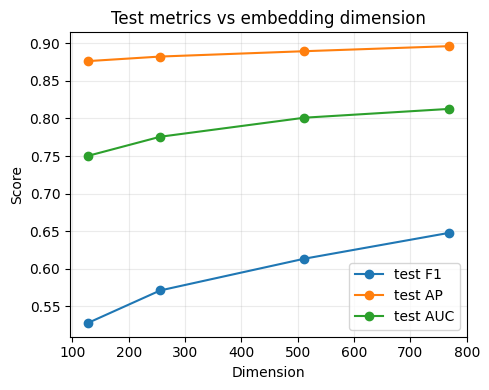

In [39]:
# --- plots ---
# fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig, axes = plt.subplots(1, 1, figsize=(5, 4))

# Encoding times
# axes[0].plot(results_dims_df["dim"], results_dims_df["encode_train_s"], marker="o", label="encode train")
# axes[0].plot(results_dims_df["dim"], results_dims_df["encode_test_s"], marker="o", label="encode test")
# axes[0].plot(results_dims_df["dim"], results_dims_df["encode_total_s"], marker="o", label="encode total")
# axes[0].set_title("Encoding time vs embedding dimension")
# axes[0].set_xlabel("Dimension")
# axes[0].set_ylabel("Time (s)")
# axes[0].grid(alpha=0.25)
# axes[0].legend()

# Test metrics
# axes[1].plot(results_dims_df["dim"], results_dims_df["test_f1"], marker="o", label="test F1")
# axes[1].plot(results_dims_df["dim"], results_dims_df["test_ap"], marker="o", label="test AP")
# axes[1].plot(results_dims_df["dim"], results_dims_df["test_auc"], marker="o", label="test AUC")
# axes[1].set_title("Test metrics vs embedding dimension")
# axes[1].set_xlabel("Dimension")
# axes[1].set_ylabel("Score")
# axes[1].grid(alpha=0.25)
# axes[1].legend()

plt.plot(results_dims_df["dim"], results_dims_df["test_f1"], marker="o", label="test F1")
plt.plot(results_dims_df["dim"], results_dims_df["test_ap"], marker="o", label="test AP")
plt.plot(results_dims_df["dim"], results_dims_df["test_auc"], marker="o", label="test AUC")
plt.title("Test metrics vs embedding dimension")
plt.xlabel("Dimension")
plt.ylabel("Score")
plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()
plt.savefig("images/pretest/embeddings_size_score.pdf")
plt.show()

### This is an exepriment !

In [50]:
# POS tag 

In [69]:
prep = Preprocessing(low_case = False,
                rm_punctuation = False,
                rm_number = False,
                word_norm = None, # stem faster
                pos_tagging = True, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

def get_pos_text(X):
    final_pos = []
    for text in X:
        _, pos_tag = prep.process(text)
        tags_l = []
        for tags in pos_tag:
            tags_l.append(tags[1])
        final_pos.append(tags_l)
    return final_pos

In [72]:
pos_train = get_pos_text(X_train)

In [ ]:
from nltk.tag.crf import CRFTagger
tagger = CRFTagger()

## Re baseline

In [ ]:
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score, precision_score, recall_score    

f1_train, f1_test = f1_score(y_train, np.ones(len(y_train)), average='macro'), f1_score(y_test, np.ones(len(y_test)), average='macro')
ap_train, ap_test = average_precision_score(y_train, np.ones(len(y_train))), average_precision_score(y_test, np.ones(len(y_test)))
auc_train, auc_test = roc_auc_score(y_train, np.ones(len(y_train))), roc_auc_score(y_test, np.ones(len(y_test)))
prec_train, prec_test = precision_score(y_train, np.ones(len(y_train))), precision_score(y_test, np.ones(len(y_test)), average='macro')
rec_train, rec_test = recall_score(y_train, np.ones(len(y_train))), recall_score(y_test, np.ones(len(y_test)), average='macro')

print(auc_train, auc_test)
print(f1_train, f1_test)
print(ap_train, ap_test)
print(rec_train, rec_test)
print(prec_train, prec_test)

0.5 0.5
0.4649472286293423 0.46493639625366945
0.8689745264532985 0.8689366890185491
1.0 0.5
0.8689745264532985 0.4344683445092746


/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [58]:
np.random.seed(0)
n_runs = 30

f1_train_scores, f1_test_scores = [], []
ap_train_scores, ap_test_scores = [], []
auc_train_scores, auc_test_scores = [], []
prec_train_scores, prec_test_scores = [], []
rec_train_scores, rec_test_scores = [], []

for _ in range(n_runs):
    a = np.random.choice([-1, 1], size=len(y_train))
    b = np.random.choice([-1, 1], size=len(y_test))

    f1_train_scores.append(f1_score(y_train, a, average="macro"))
    f1_test_scores.append(f1_score(y_test, b, average="macro"))

    ap_train_scores.append(average_precision_score(y_train, a))
    ap_test_scores.append(average_precision_score(y_test, b))

    auc_train_scores.append(roc_auc_score(y_train, np.where(a == 1, 1, 0)))
    auc_test_scores.append(roc_auc_score(y_test, np.where(b == 1, 1, 0)))

    prec_train_scores.append(precision_score(y_train, a, average='macro'))
    prec_test_scores.append(precision_score(y_test, b, average='macro'))

    rec_train_scores.append(recall_score(y_train, a, average='macro'))
    rec_test_scores.append(recall_score(y_test, b, average='macro'))

print("Mean over 30 random runs:")
print("AUC:", np.mean(auc_train_scores), np.mean(auc_test_scores))
print("F1:", np.mean(f1_train_scores), np.mean(f1_test_scores))
print("AP:", np.mean(ap_train_scores), np.mean(ap_test_scores))
print("Recall:", np.mean(rec_train_scores), np.mean(rec_test_scores))
print("Precision:", np.mean(prec_train_scores), np.mean(prec_test_scores))

Mean over 30 random runs:
AUC: 0.5008081654681841 0.4998535216013436
F1: 0.4214766679305052 0.42074730693105805
AP: 0.8691598115777023 0.8689088772530399
Recall: 0.5008081654681842 0.49985352160134355
Precision: 0.5003680675841884 0.49993328426316347
